In [1]:
# Author: M. Riley Owens (GitHub: mrileyowens)

# Plot low-EW galaxies from Endsley et al. (2024)

In [2]:
import sys

import os
import glob

import h5py

import numpy as np

from astropy.io import fits

import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))

from mrileyowens.stats import weighted_quantile
from mrileyowens.beagle import ew

/Users/a15136/Documents/research/mrileyowens/beagle.py:34: SyntaxWarning: invalid escape sequence '\s'
  'sigma' : ['GALAXY PROPERTIES', '\sigma', 1, 'km s$^{-1}$'],
/Users/a15136/Documents/research/mrileyowens/beagle.py:35: SyntaxWarning: invalid escape sequence '\o'
  'M_tot' : ['GALAXY PROPERTIES', r'M_{{\rm tot}}', 1e6, 'MM$_\odot$'],
/Users/a15136/Documents/research/mrileyowens/beagle.py:36: SyntaxWarning: invalid escape sequence '\o'
  'M_star' : ['GALAXY PROPERTIES', r'M_{{\rm star}}', 1e6, 'MM$_\odot$'],
/Users/a15136/Documents/research/mrileyowens/beagle.py:37: SyntaxWarning: invalid escape sequence '\o'
  'M_liv' : ['GALAXY PROPERTIES', r'M_{{\rm liv}}', 1e6, 'MM$_\odot$'],
/Users/a15136/Documents/research/mrileyowens/beagle.py:38: SyntaxWarning: invalid escape sequence '\_'
  'M_remnants' : ['GALAXY PROPERTIES', r'M_{{\rm remnants}}', 1e6, 'MM$\_odot$'],
/Users/a15136/Documents/research/mrileyowens/beagle.py:50: SyntaxWarning: invalid escape sequence '\o'
  'SFR' : ['STAR FO

In [3]:
def compare():

    home = os.getcwd()
    data = f'{home}/data'
    figs = f'{home}/figs'
    results = f'{home}/results'

    catalog = f'{data}/JADES_z6to9LBGcatalog_Endsley2024_f775w_dropouts.fits'
    hdul_endsley2024 = fits.open(catalog)

    ews_endsley2024 = hdul_endsley2024[1].data['OIIIHbEw']

    ids_endsley2024 = hdul_endsley2024[1].data['ID'][ews_endsley2024 < 100]

    #files = glob.glob([f'for id in ids_endsley2024])
    files = [f'{results}/beagle_fits/JADES_z6to9LBGcatalog_Endsley2024_f775w_dropouts_beagle_csfh_fits/{id}_BEAGLE.fits.gz' for id in ids_endsley2024]

    lines = {
        'hbeta' : ['H$\\beta$', [[4856,4866]], [[4775,4825], [4880,4930]]],
        'oiii' : ['[O III]', [[4954,5011]], [[4880,4930], [5050,5100]]]
    }

    ew(files, lines, output=None, redshifts=None, plot=True)
    #m_uv_bins = ['bright', 'faint', 'vfaint']

    #fig, ax = plt.subplots()

    '''
    for m_uv_bin in m_uv_bins:

        with h5py.File(f'{results}/ew/JADES_z6to9LBGcatalog_Endsley2024_f775w_dropouts_beagle_csfh_fits_ews_{m_uv_bin}.h5', 'r') as f:

            for i, id in enumerate(list(f.keys())):

                ew_posterior_me = f[id]['hb_ews'][:] + f[id]['oiii_ews'][:]
                probs = f[id]['probabilities'][:]

                ew_me, ew_lower, ew_upper = weighted_quantile(ew_posterior_me, probs, [0.5, 0.16, 0.84])

                ew_endsley2024, ew_endsley2024_lower, ew_endsley2024_upper = hdul_endsley2024[1].data['OIIIHbEw'][ids_endsley2024 == id][0], hdul_endsley2024[1].data['OIIIHbEw_l16'][ids_endsley2024 == id][0], hdul_endsley2024[1].data['OIIIHbEw_u84'][ids_endsley2024 == id][0]

                ax.errorbar(ew_me, ew_endsley2024, xerr=[[ew_me - ew_lower], [ew_upper - ew_me]], yerr=[[ew_endsley2024 - ew_endsley2024_lower], [ew_endsley2024_upper - ew_endsley2024]], color='black')
    '''

    #ax.set_xlabel('log$_{10}$(EW([O III] + H$\\beta$) / $\AA$) (Me)')
    #ax.set_ylabel('log$_{10}$(EW([O III] + H$\\beta$) / $\AA$) (Endsley et al. (2024))')

    ## Create a one-to-one line on the figure
    #ax.axline((1000,1000), slope=1, color='red', linestyle='dashed')

    #ax.loglog()

    #fig.savefig(f'{figs}/compare_ew.png', dpi=200, bbox_inches='tight')

['/Users/a15136/Documents/research/jades_ew_dist/results/beagle_fits/JADES_z6to9LBGcatalog_Endsley2024_f775w_dropouts_beagle_csfh_fits/139505_GOODSS_BEAGLE.fits.gz', '/Users/a15136/Documents/research/jades_ew_dist/results/beagle_fits/JADES_z6to9LBGcatalog_Endsley2024_f775w_dropouts_beagle_csfh_fits/98136_GOODSS_BEAGLE.fits.gz', '/Users/a15136/Documents/research/jades_ew_dist/results/beagle_fits/JADES_z6to9LBGcatalog_Endsley2024_f775w_dropouts_beagle_csfh_fits/84655_GOODSS_BEAGLE.fits.gz', '/Users/a15136/Documents/research/jades_ew_dist/results/beagle_fits/JADES_z6to9LBGcatalog_Endsley2024_f775w_dropouts_beagle_csfh_fits/149685_GOODSS_BEAGLE.fits.gz', '/Users/a15136/Documents/research/jades_ew_dist/results/beagle_fits/JADES_z6to9LBGcatalog_Endsley2024_f775w_dropouts_beagle_csfh_fits/134083_GOODSS_BEAGLE.fits.gz', '/Users/a15136/Documents/research/jades_ew_dist/results/beagle_fits/JADES_z6to9LBGcatalog_Endsley2024_f775w_dropouts_beagle_csfh_fits/130152_GOODSS_BEAGLE.fits.gz', '/Users/a15

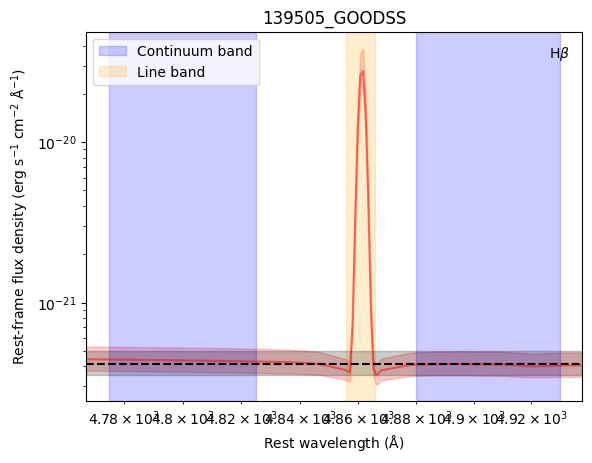

4386 1468 (1468, 4386)


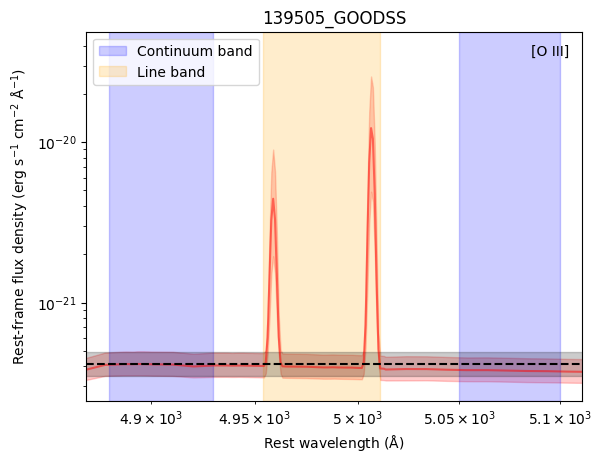

4386 2367 (2367, 4386)


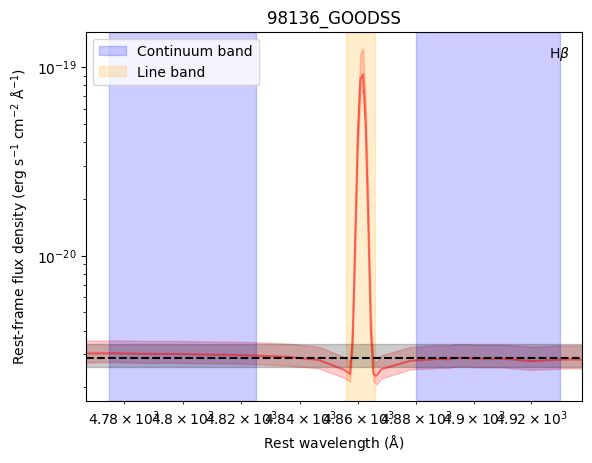

4386 2367 (2367, 4386)


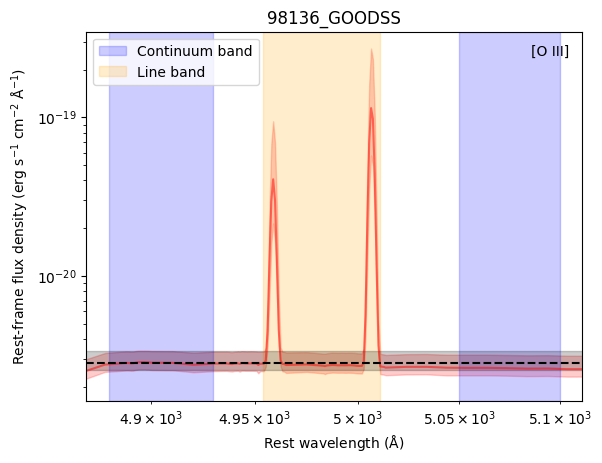

4386 1927 (1927, 4386)


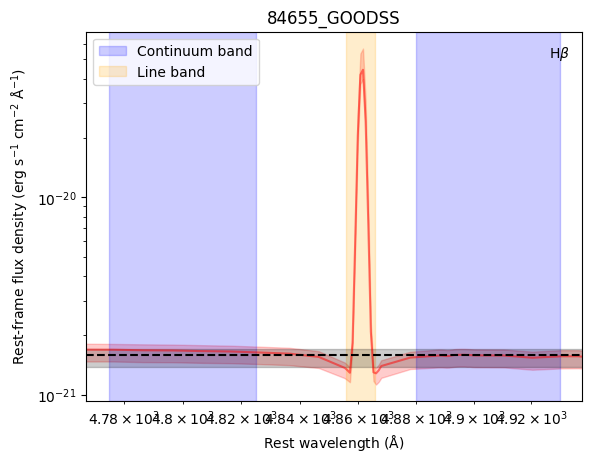

4386 1927 (1927, 4386)


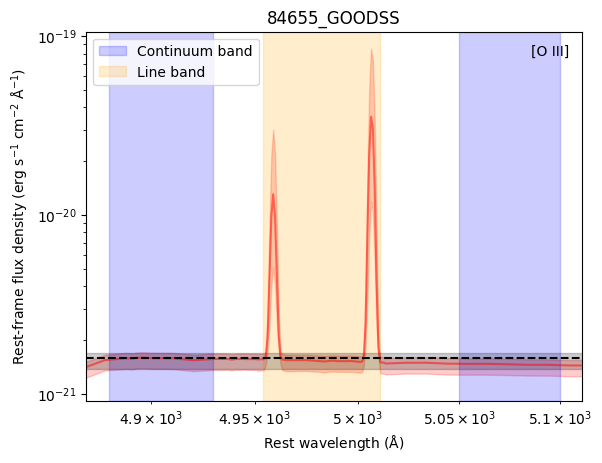

4386 2445 (2445, 4386)


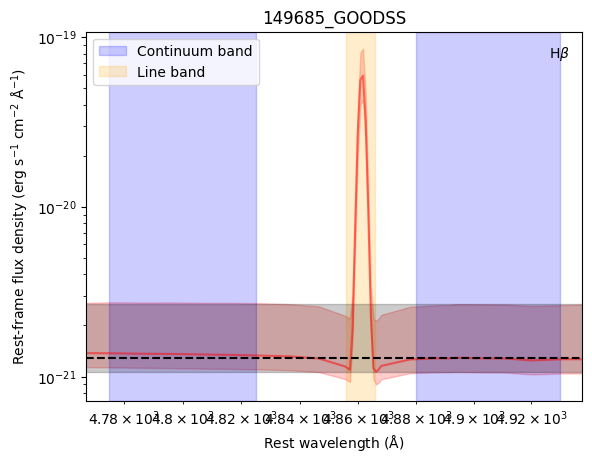

4386 2445 (2445, 4386)


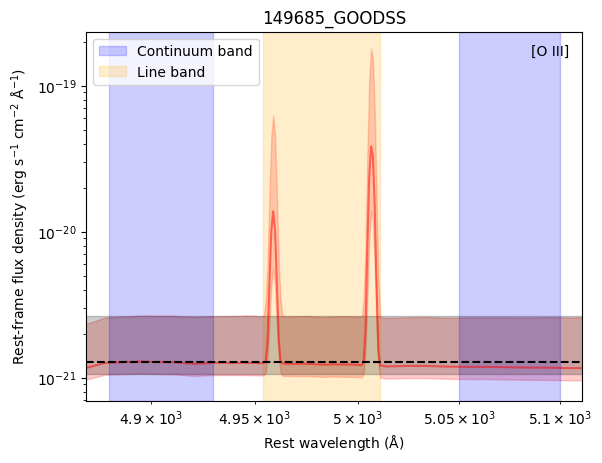

4386 1846 (1846, 4386)


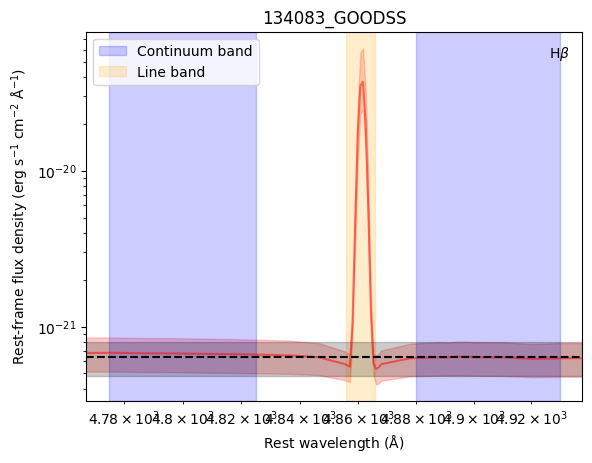

4386 1846 (1846, 4386)


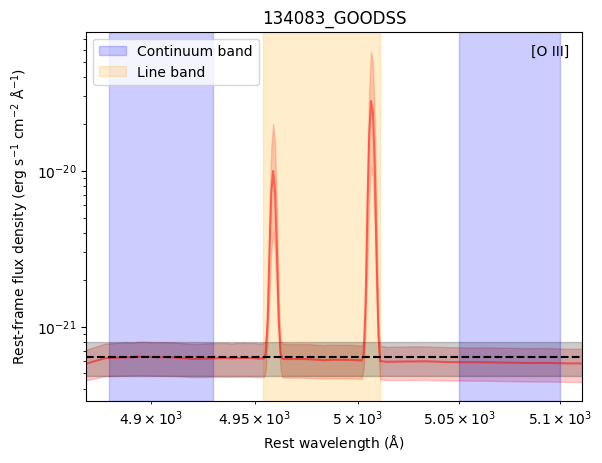

4386 2157 (2157, 4386)


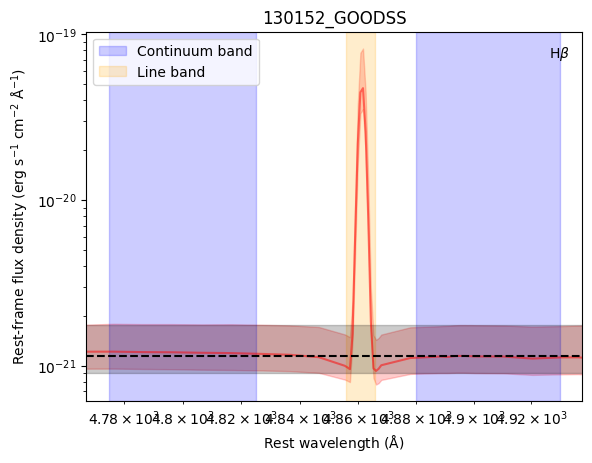

4386 2157 (2157, 4386)


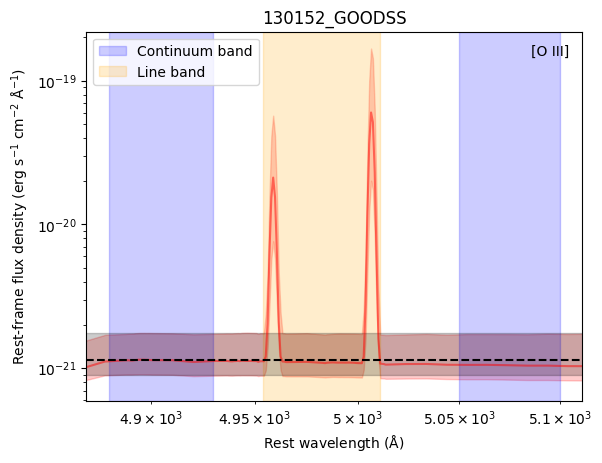

4386 2760 (2760, 4386)


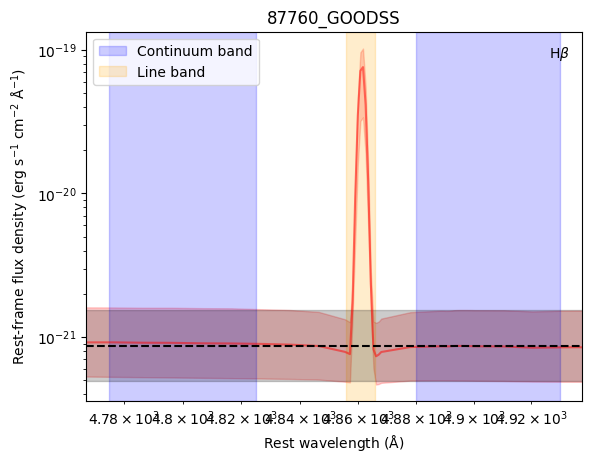

4386 2760 (2760, 4386)


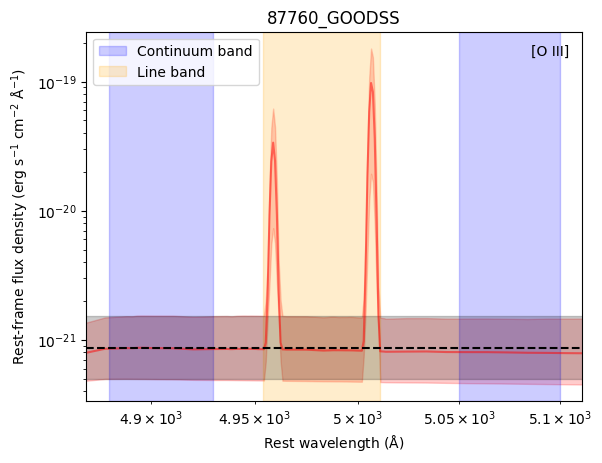

4386 2038 (2038, 4386)


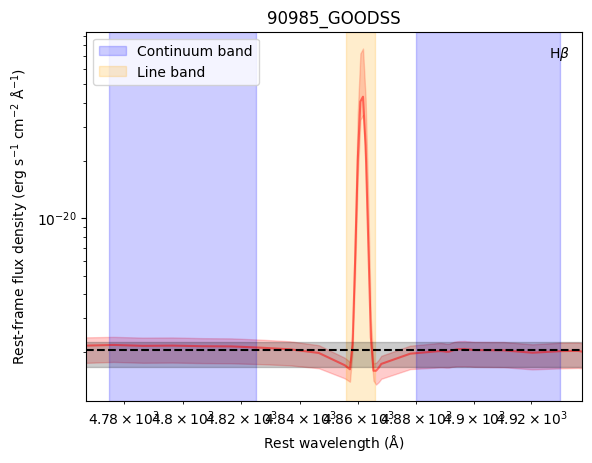

4386 2038 (2038, 4386)


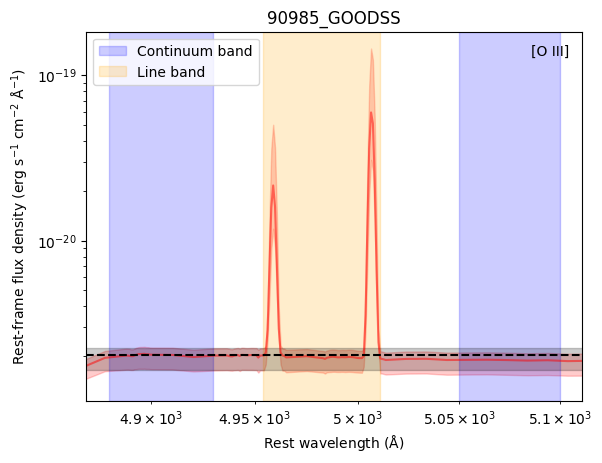

4386 1846 (1846, 4386)


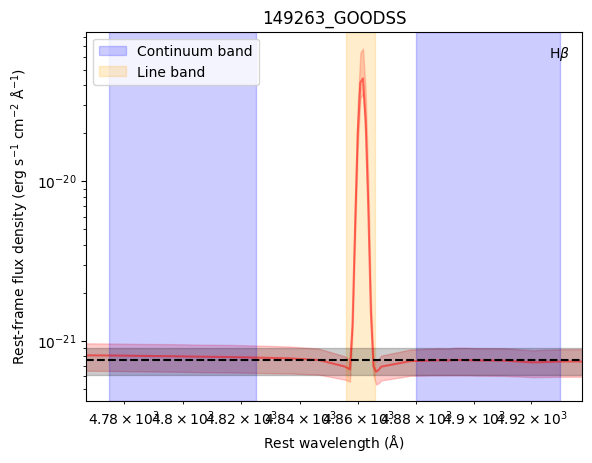

4386 1846 (1846, 4386)


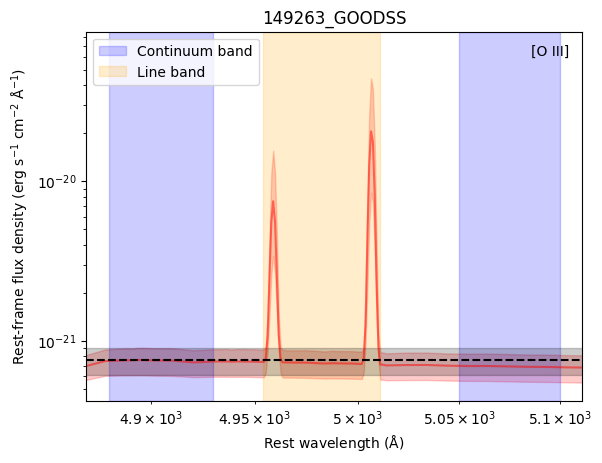

4386 2069 (2069, 4386)


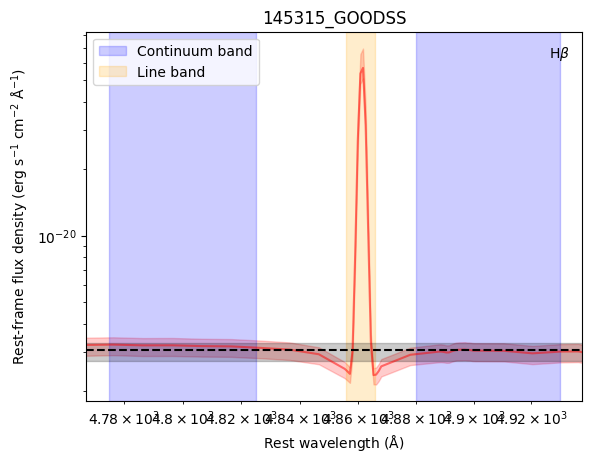

4386 2069 (2069, 4386)


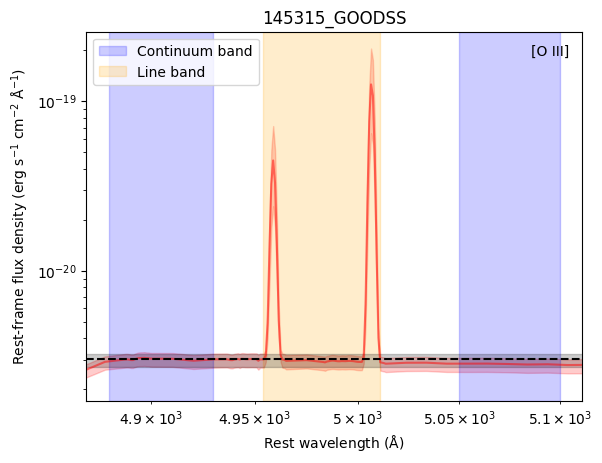

4386 2329 (2329, 4386)


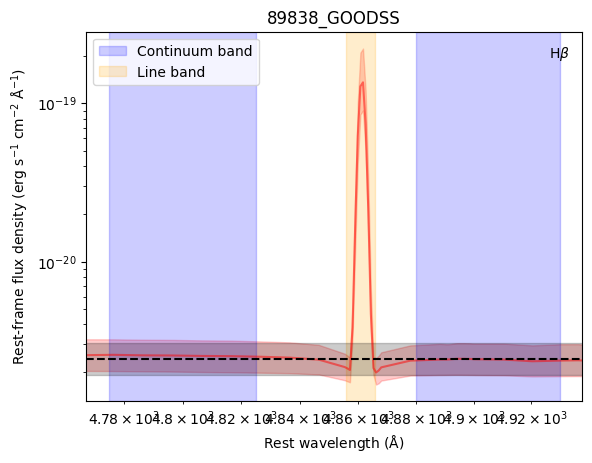

4386 2329 (2329, 4386)


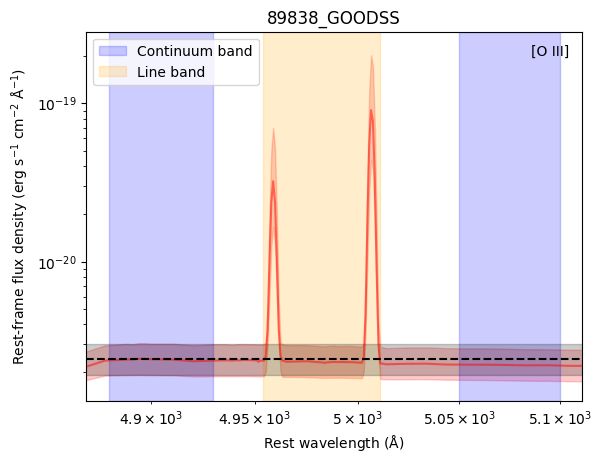

4386 1754 (1754, 4386)


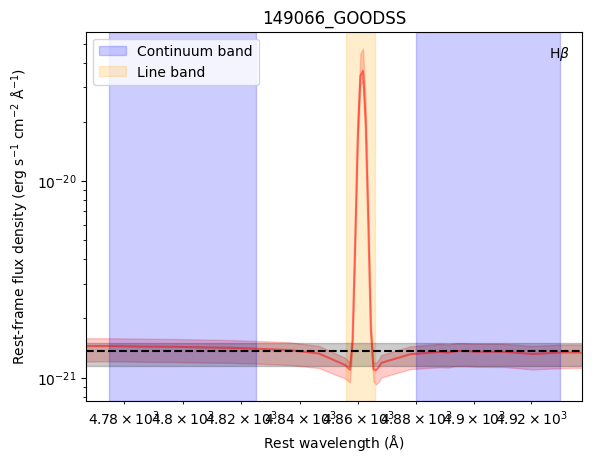

4386 1754 (1754, 4386)


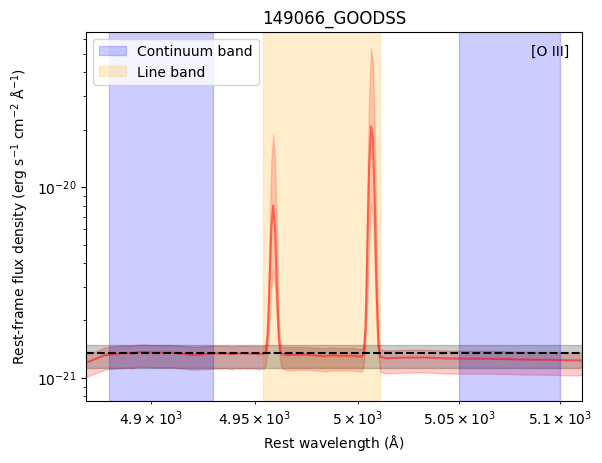

4386 2447 (2447, 4386)


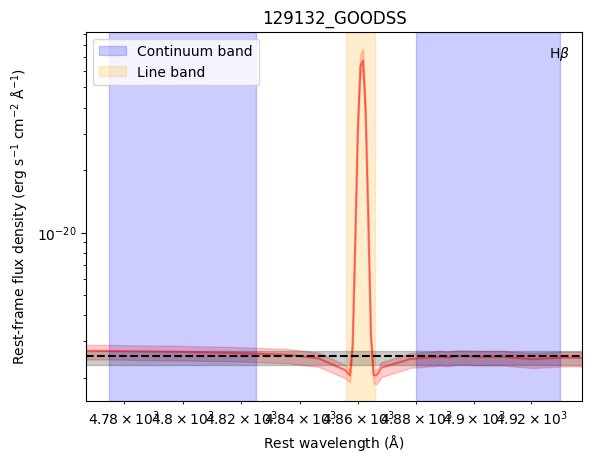

4386 2447 (2447, 4386)


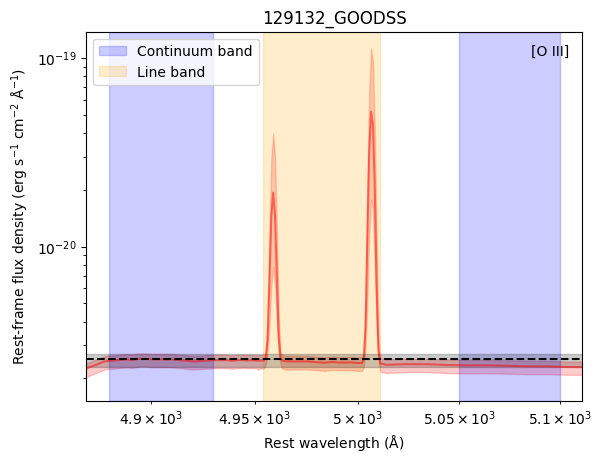

4386 2148 (2148, 4386)


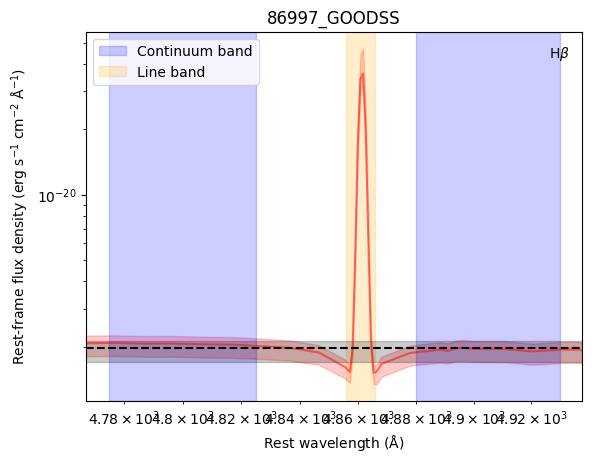

4386 2148 (2148, 4386)


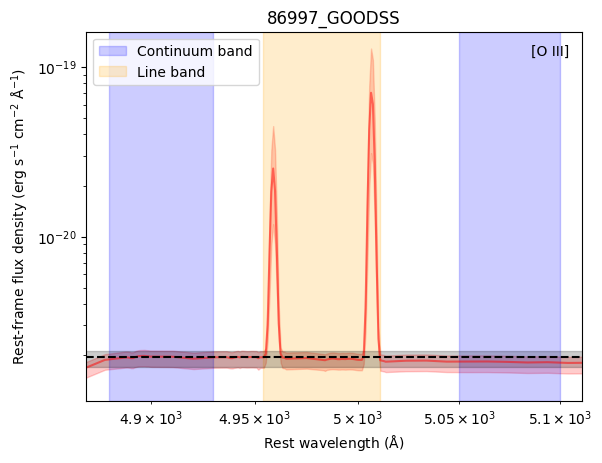

4386 2247 (2247, 4386)


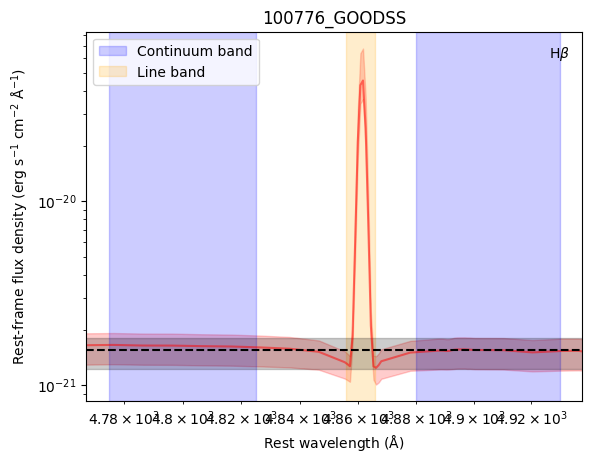

4386 2247 (2247, 4386)


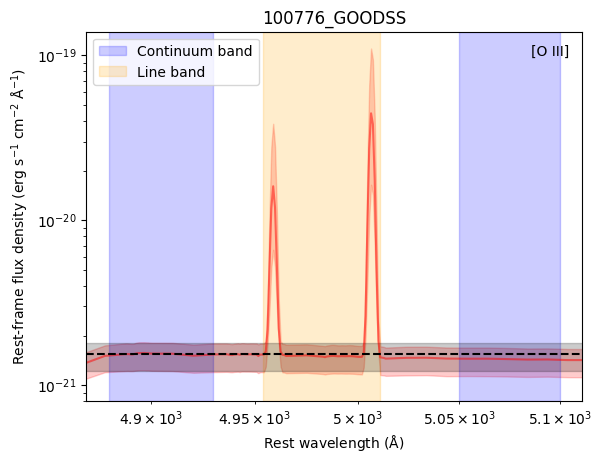

4386 3044 (3044, 4386)


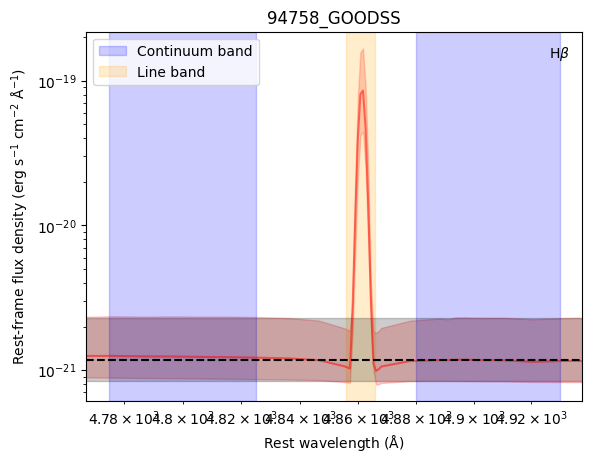

4386 3044 (3044, 4386)


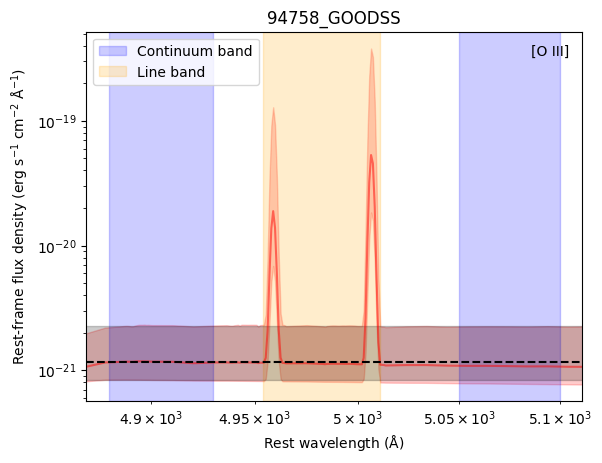

4386 1942 (1942, 4386)


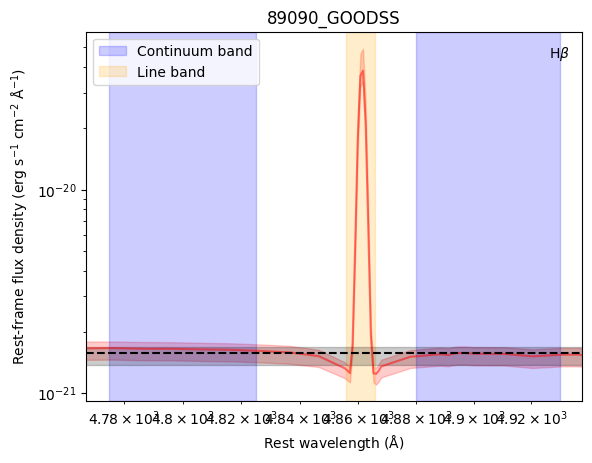

4386 1942 (1942, 4386)


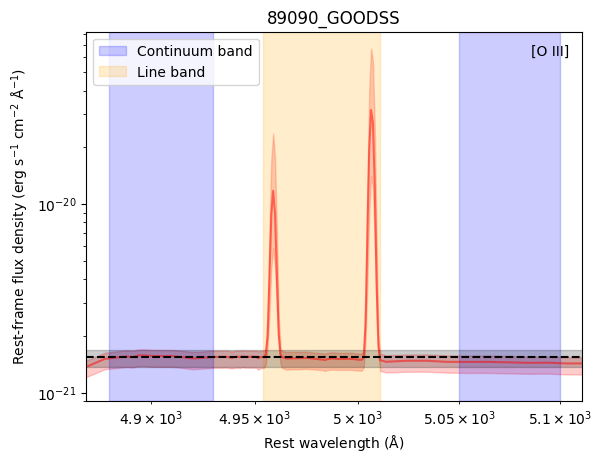

4386 1981 (1981, 4386)


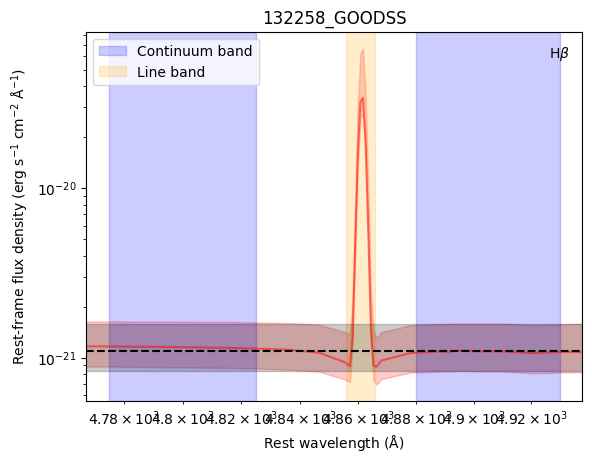

4386 1981 (1981, 4386)


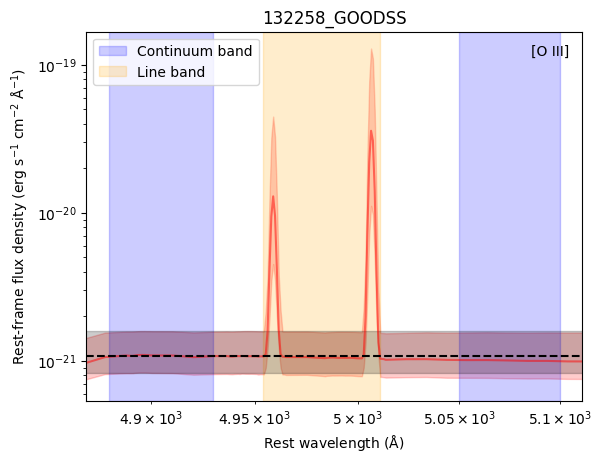

4386 2397 (2397, 4386)


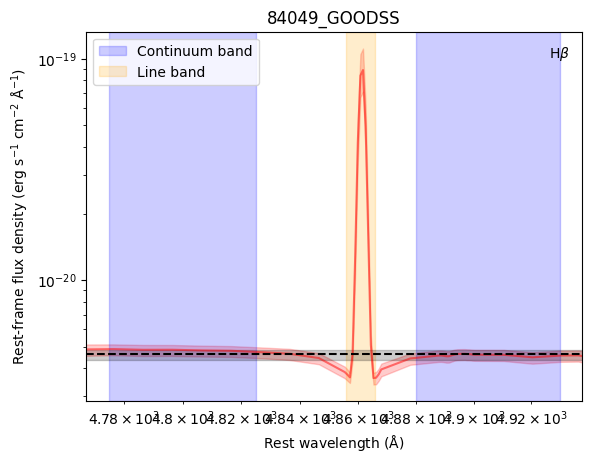

4386 2397 (2397, 4386)


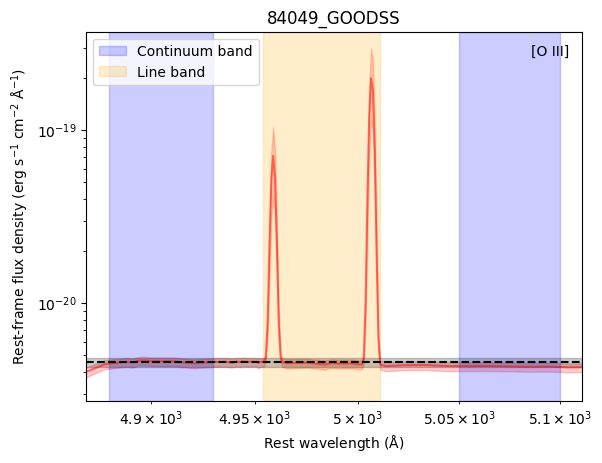

4386 1914 (1914, 4386)


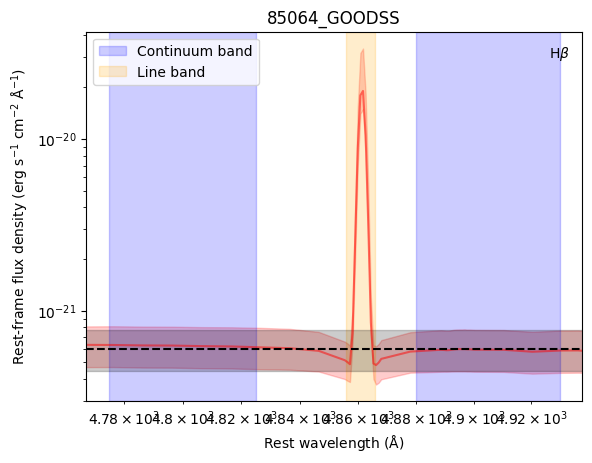

4386 1914 (1914, 4386)


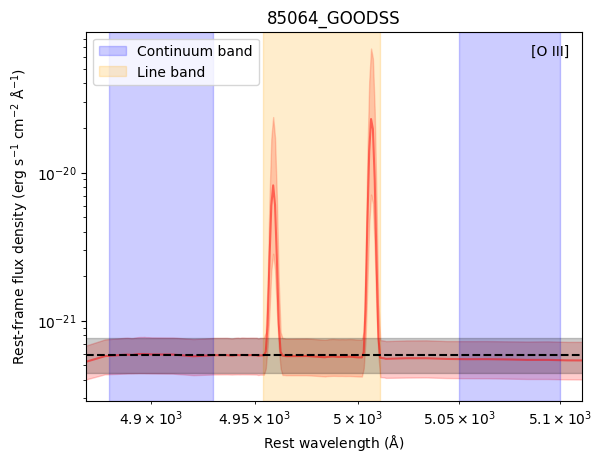

4386 2591 (2591, 4386)


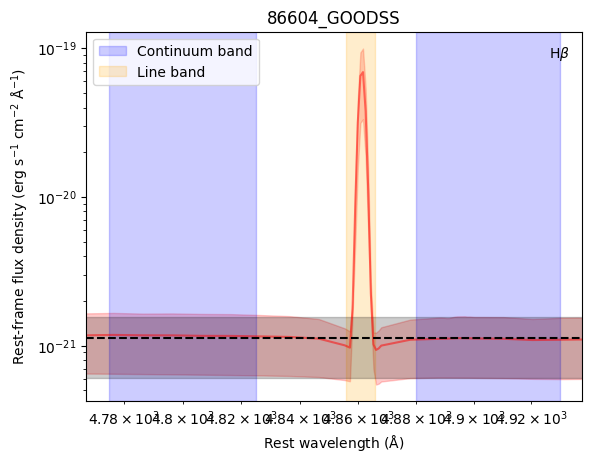

4386 2591 (2591, 4386)


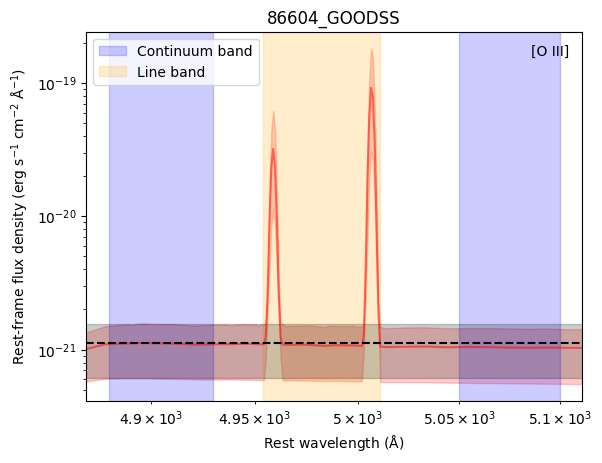

4386 1662 (1662, 4386)


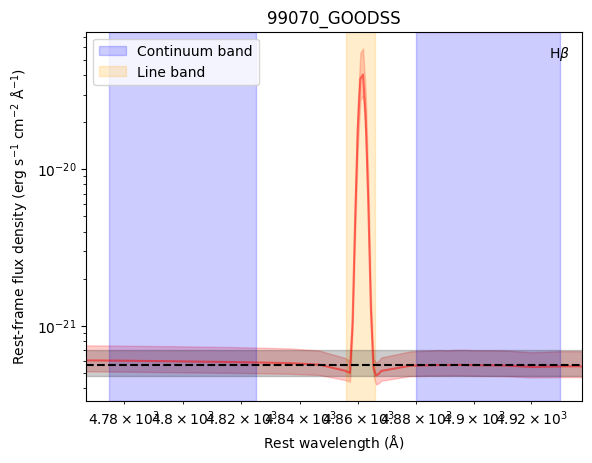

4386 1662 (1662, 4386)


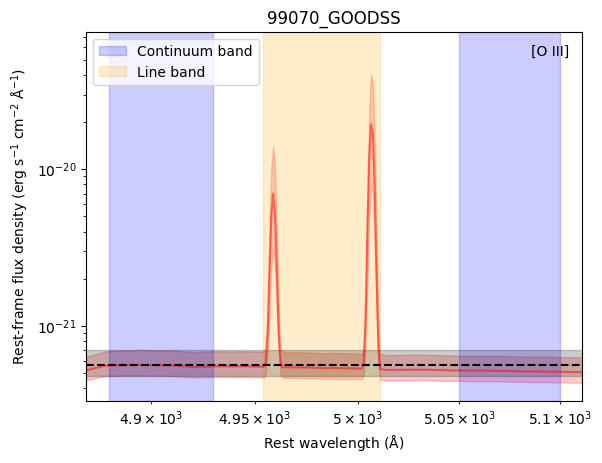

4386 2507 (2507, 4386)


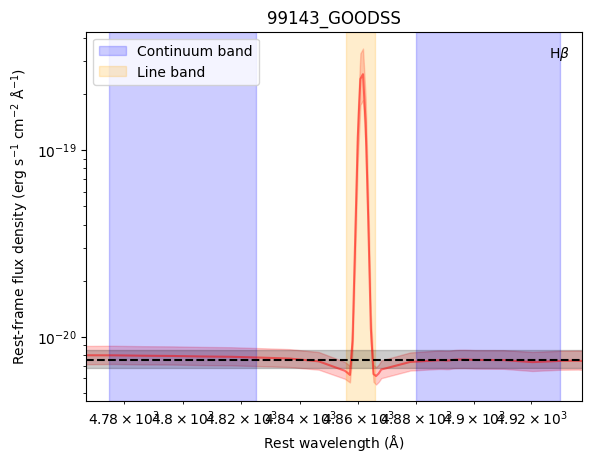

4386 2507 (2507, 4386)


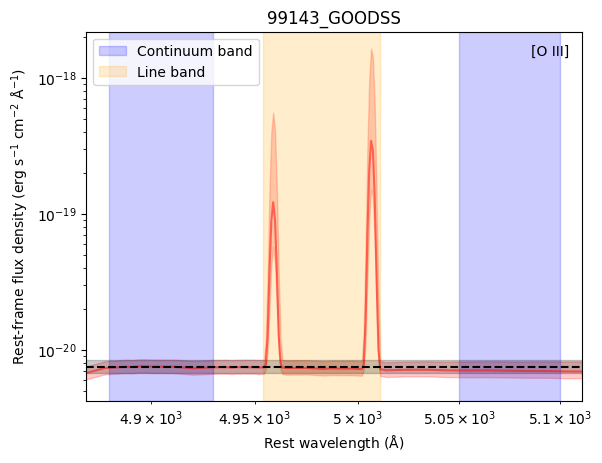

4386 1476 (1476, 4386)


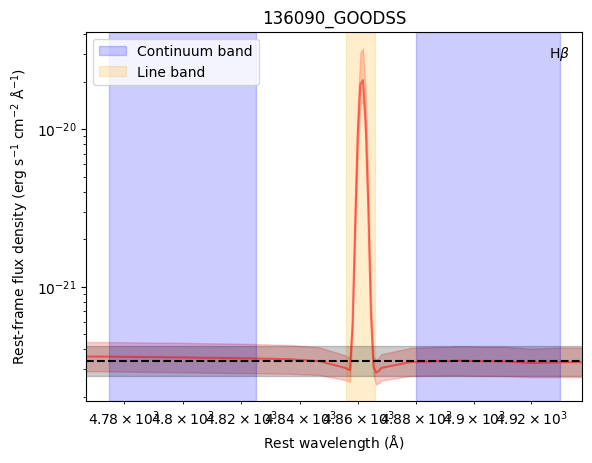

4386 1476 (1476, 4386)


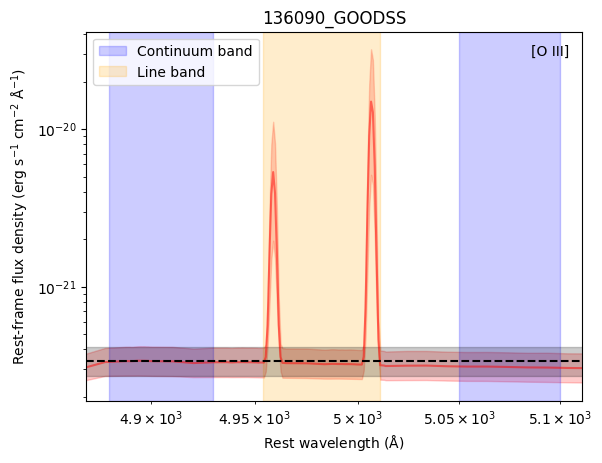

4386 1708 (1708, 4386)


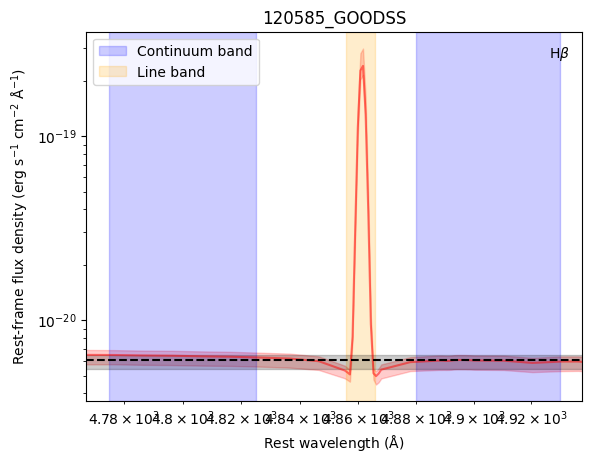

4386 1708 (1708, 4386)


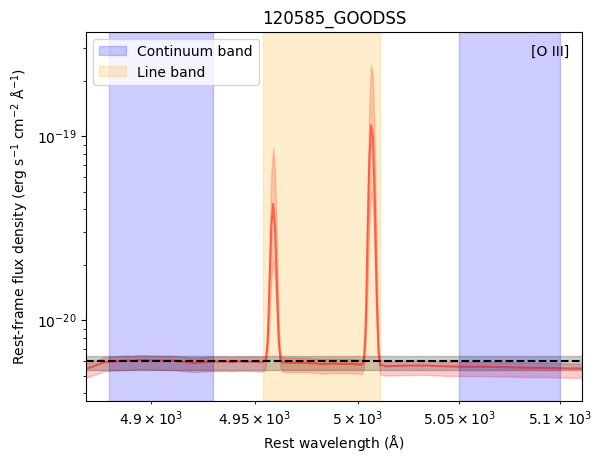

4386 1883 (1883, 4386)


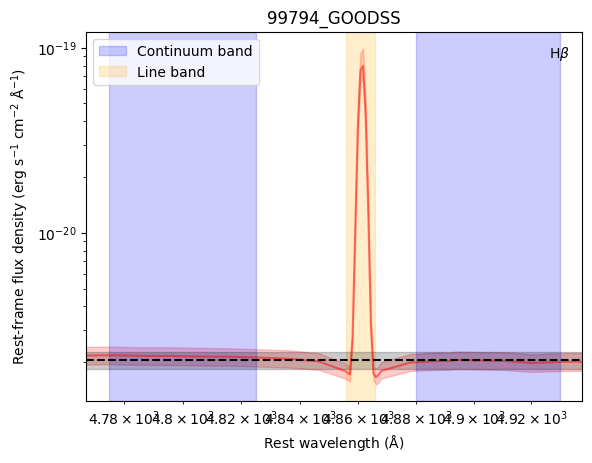

4386 1883 (1883, 4386)


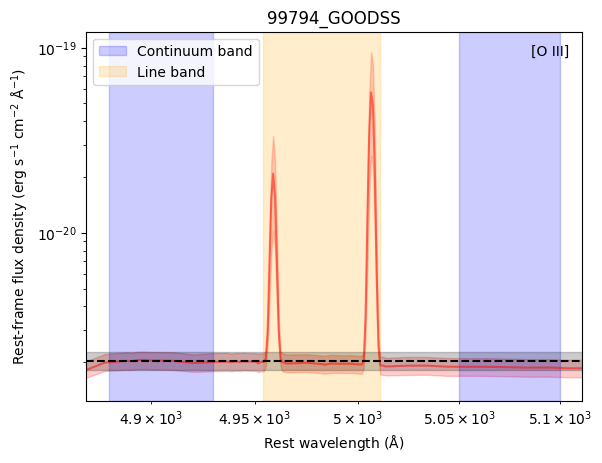

4386 2742 (2742, 4386)


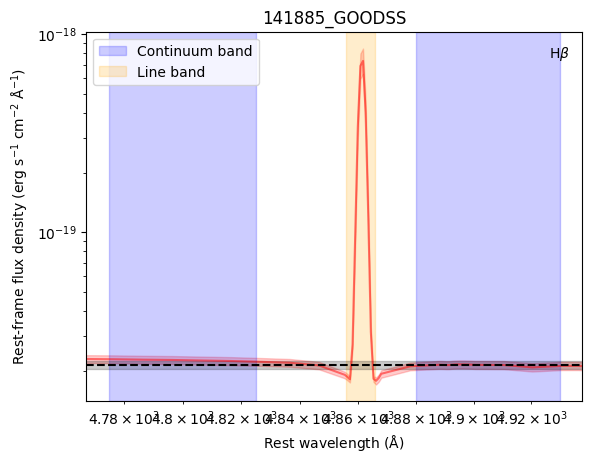

4386 2742 (2742, 4386)


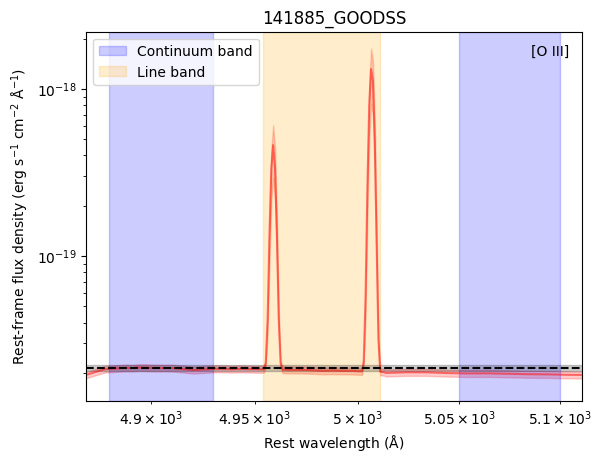

4386 1853 (1853, 4386)


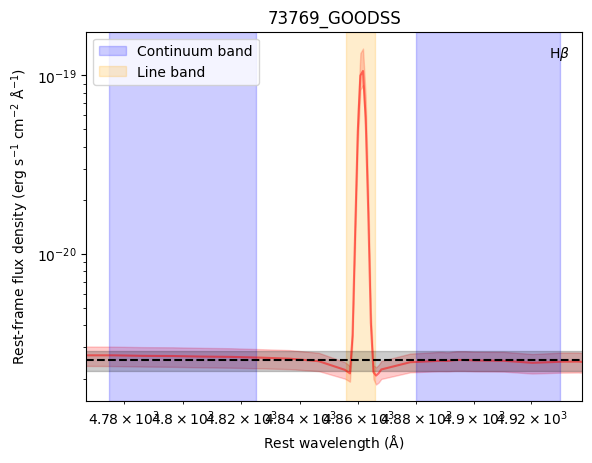

4386 1853 (1853, 4386)


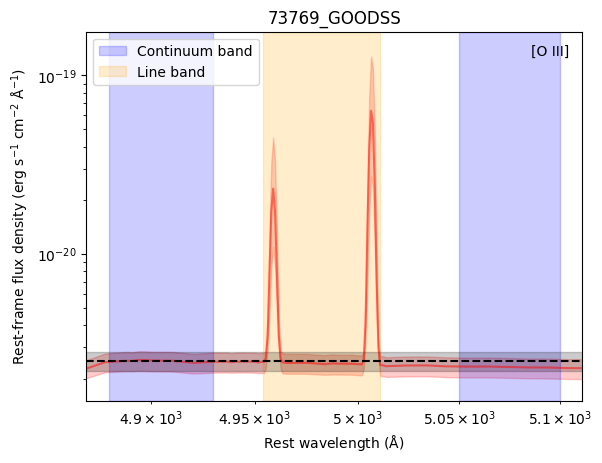

4386 2302 (2302, 4386)


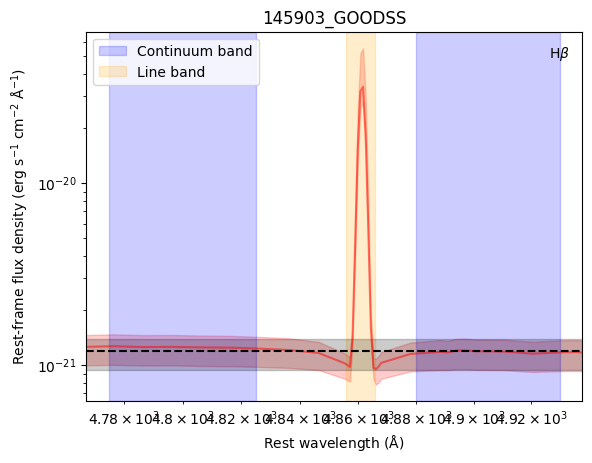

4386 2302 (2302, 4386)


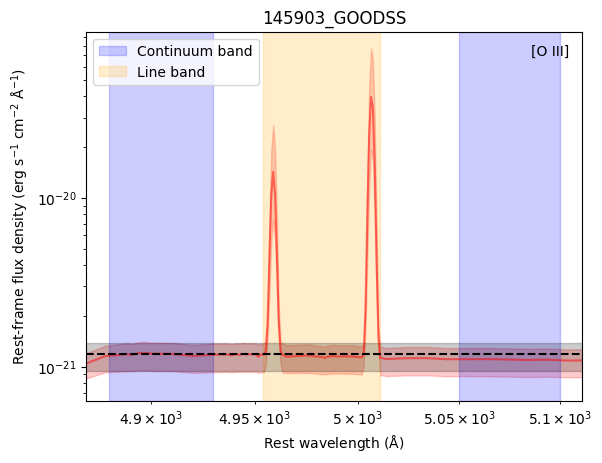

4386 2401 (2401, 4386)


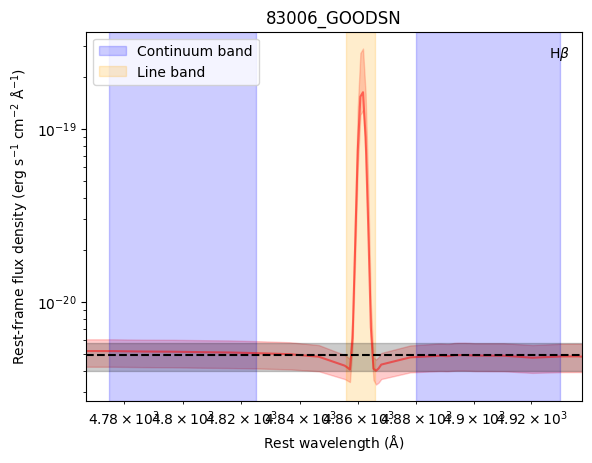

4386 2401 (2401, 4386)


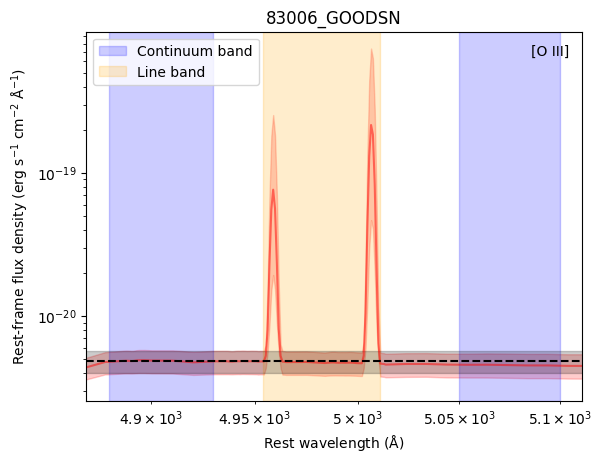

4386 2076 (2076, 4386)


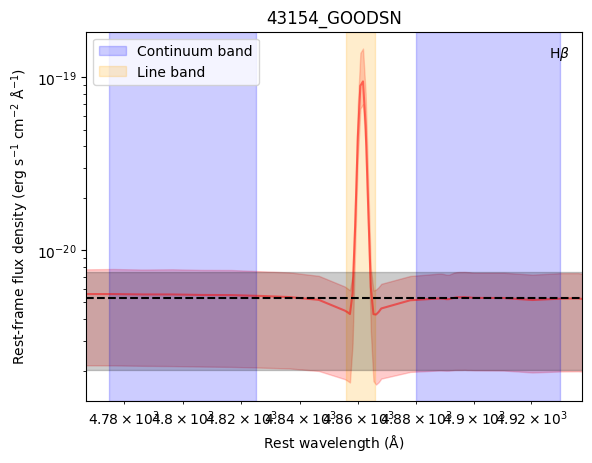

4386 2076 (2076, 4386)


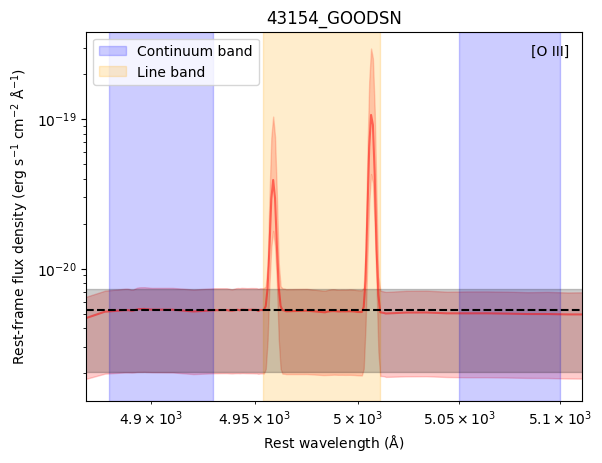

4386 3025 (3025, 4386)


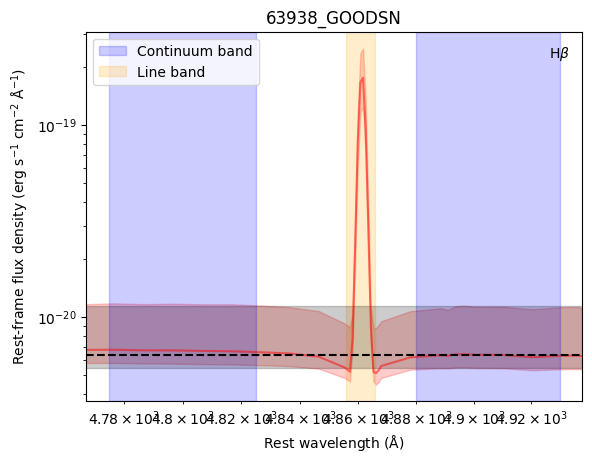

4386 3025 (3025, 4386)


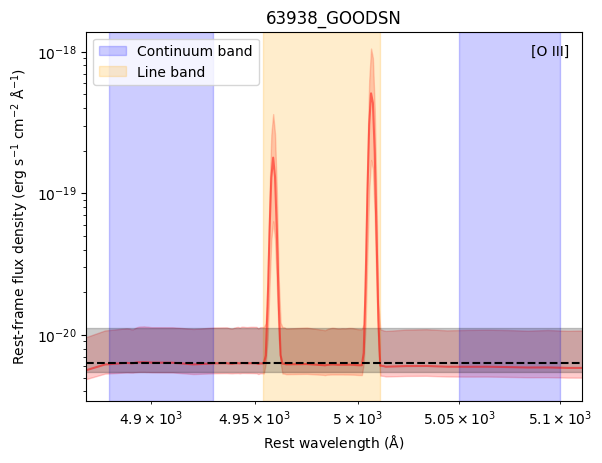

4386 2390 (2390, 4386)


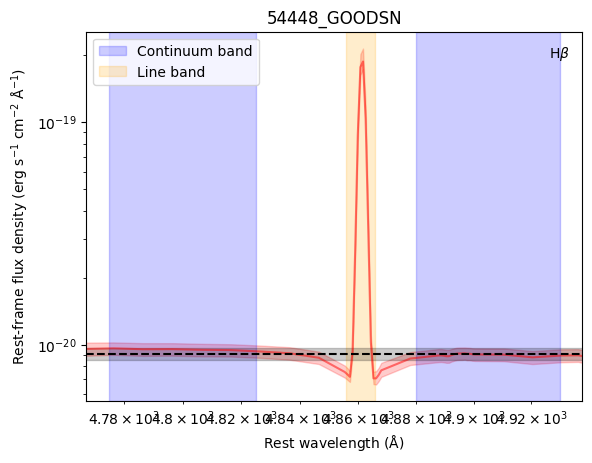

4386 2390 (2390, 4386)


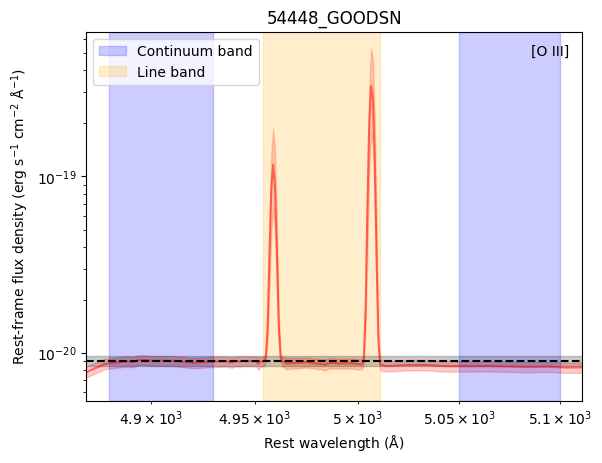

4386 2277 (2277, 4386)


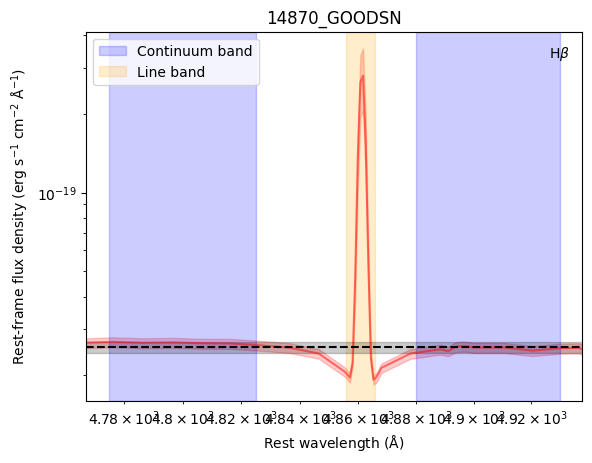

4386 2277 (2277, 4386)


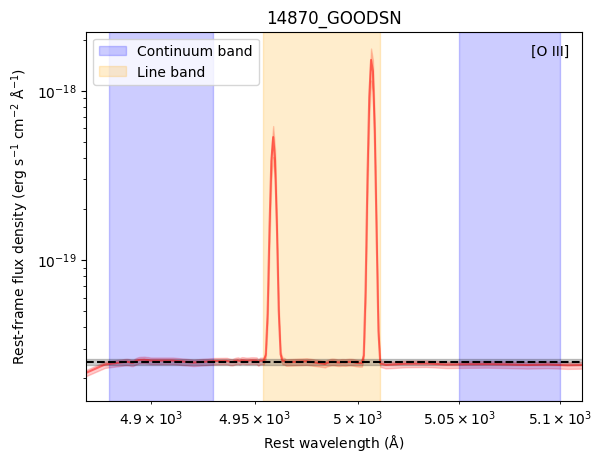

4386 2351 (2351, 4386)


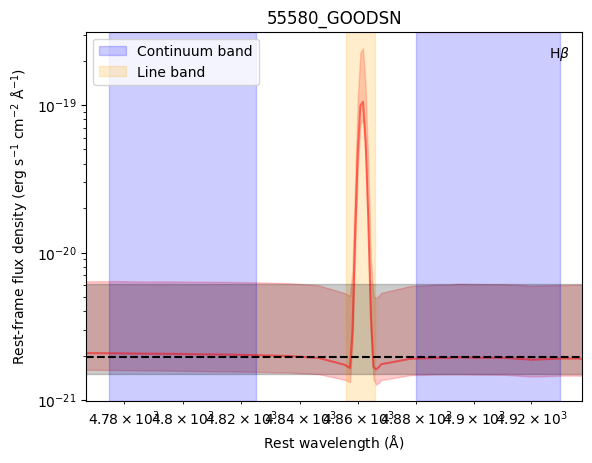

4386 2351 (2351, 4386)


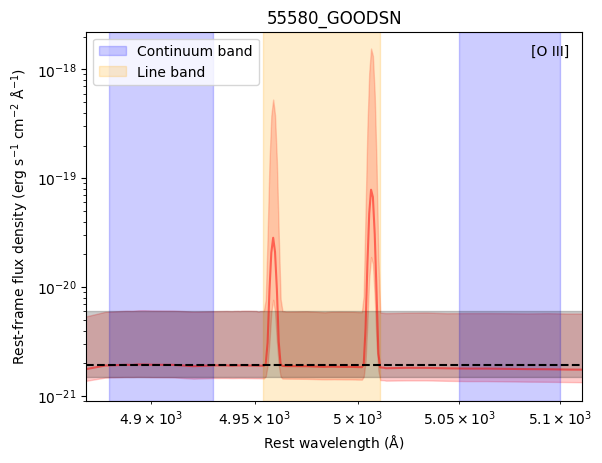

4386 2570 (2570, 4386)


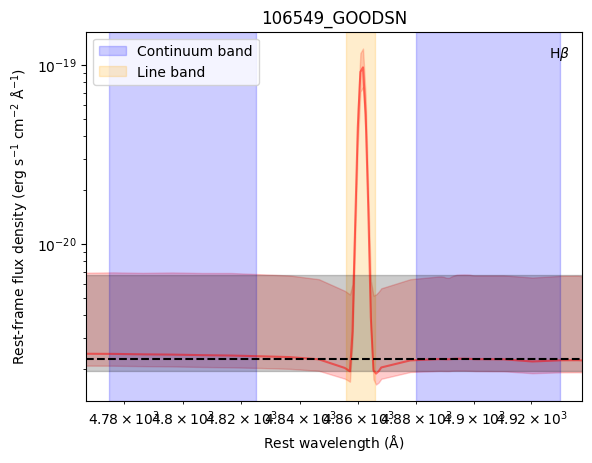

4386 2570 (2570, 4386)


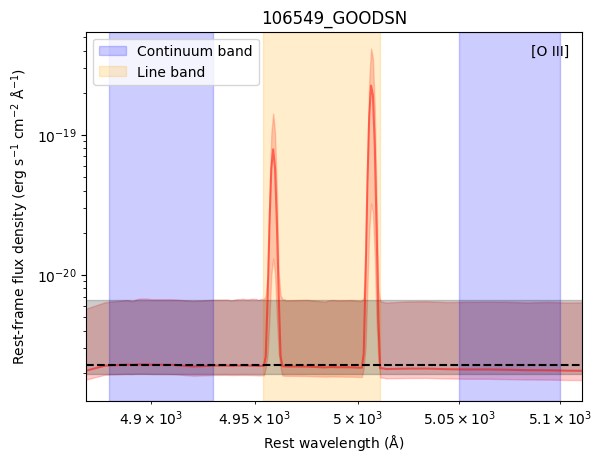

4386 2465 (2465, 4386)


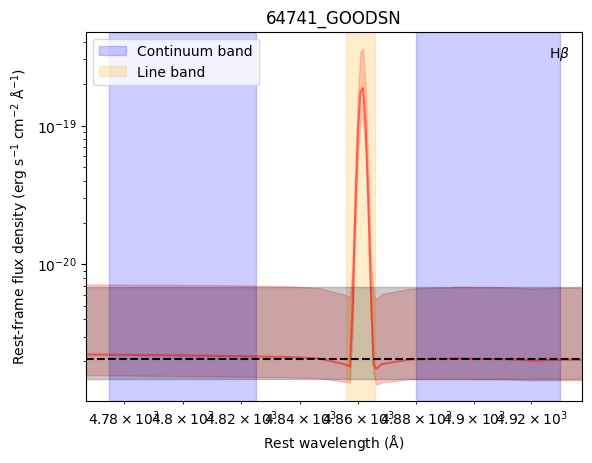

4386 2465 (2465, 4386)


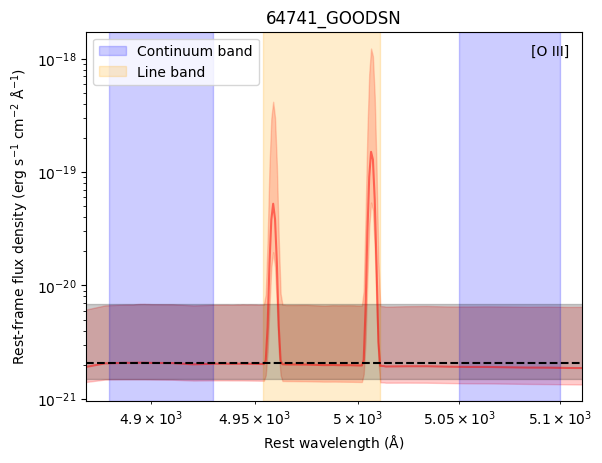

4386 2365 (2365, 4386)


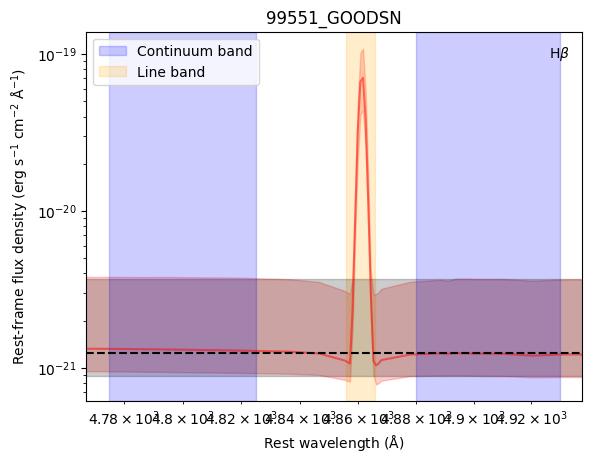

4386 2365 (2365, 4386)


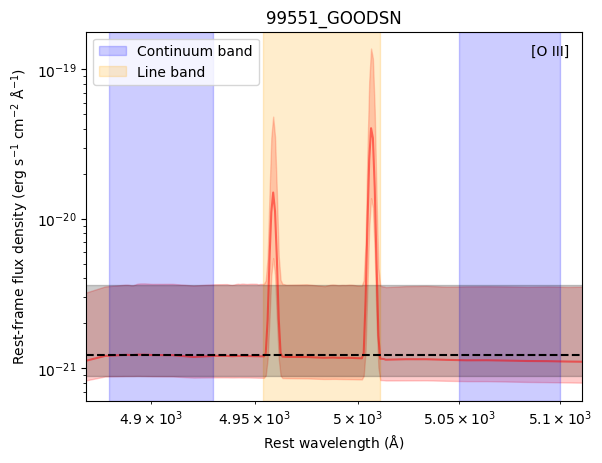

4386 2178 (2178, 4386)


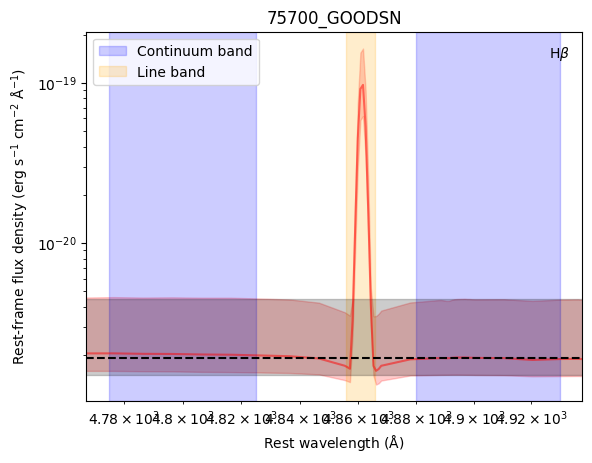

4386 2178 (2178, 4386)


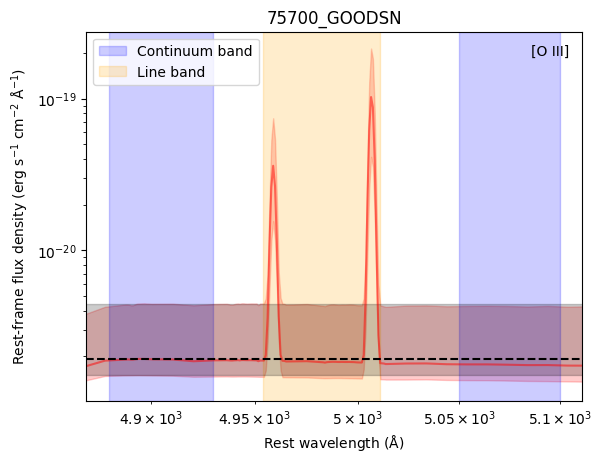

4386 2622 (2622, 4386)


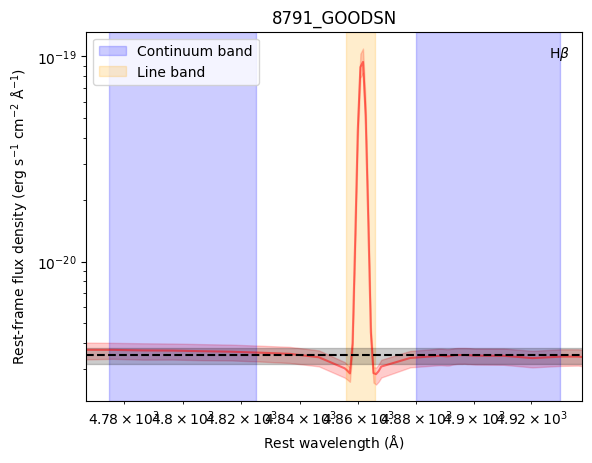

4386 2622 (2622, 4386)


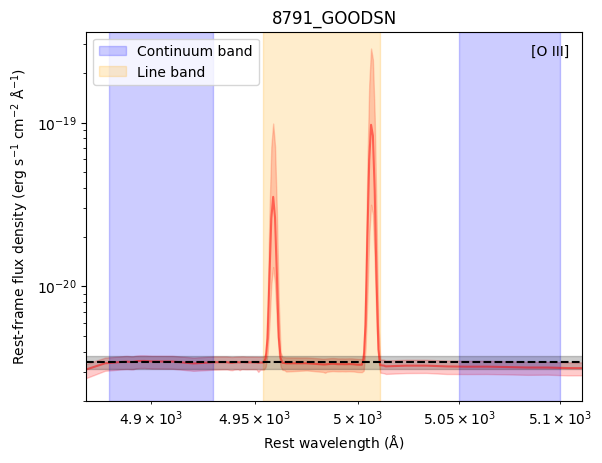

4386 2339 (2339, 4386)


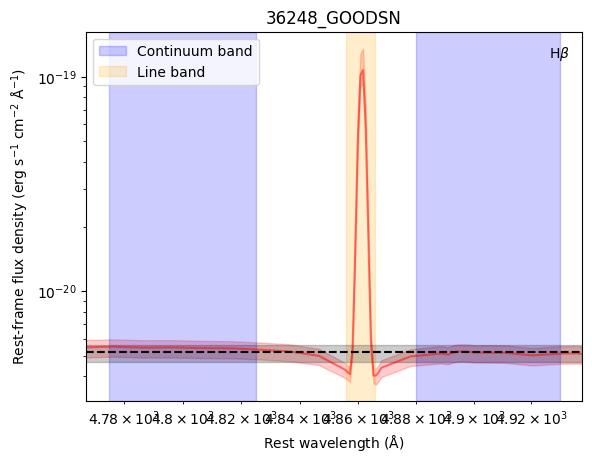

4386 2339 (2339, 4386)


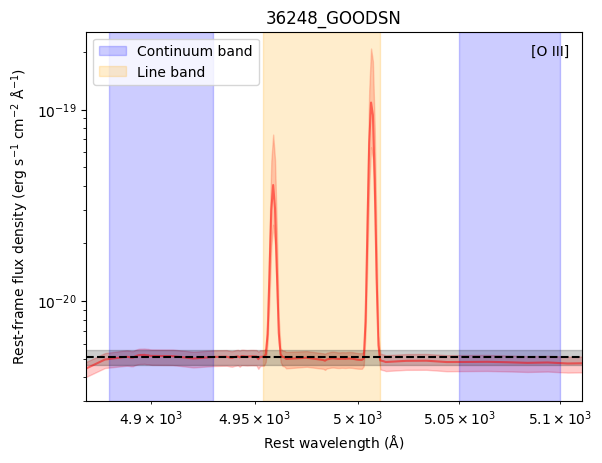

4386 2564 (2564, 4386)


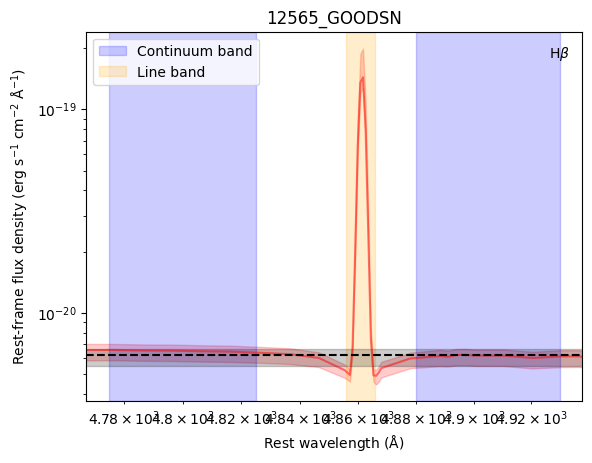

4386 2564 (2564, 4386)


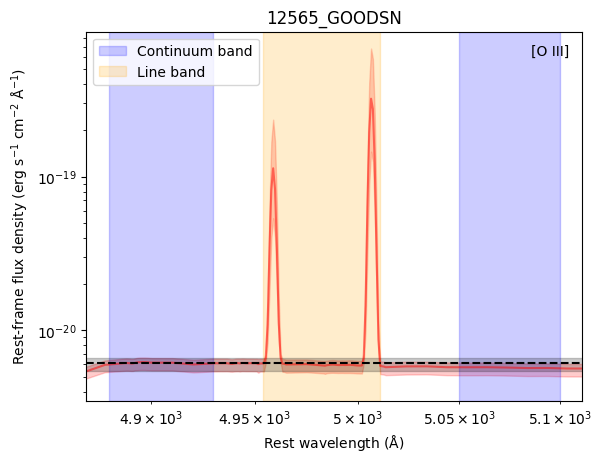

4386 2892 (2892, 4386)


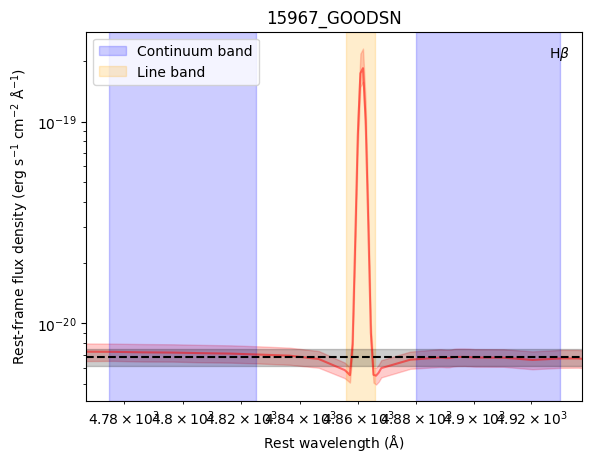

4386 2892 (2892, 4386)


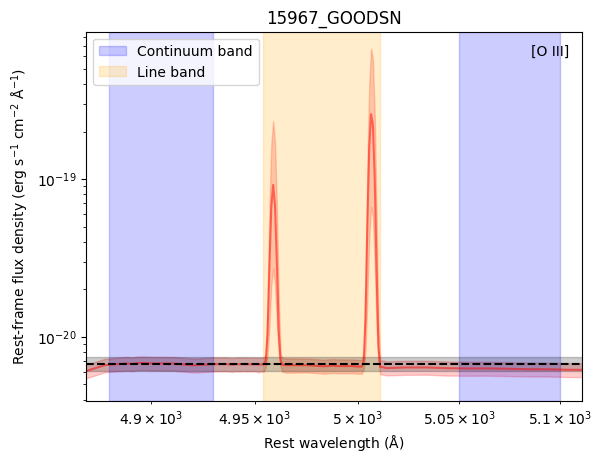

4386 2396 (2396, 4386)


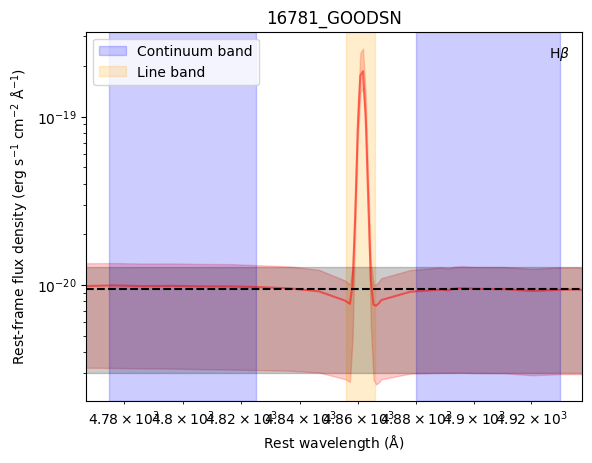

4386 2396 (2396, 4386)


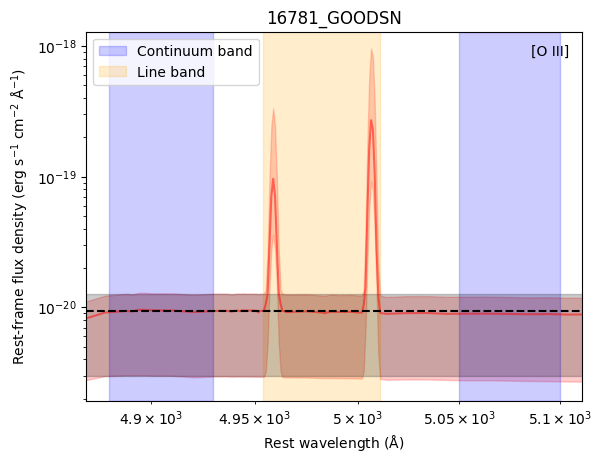

4386 2357 (2357, 4386)


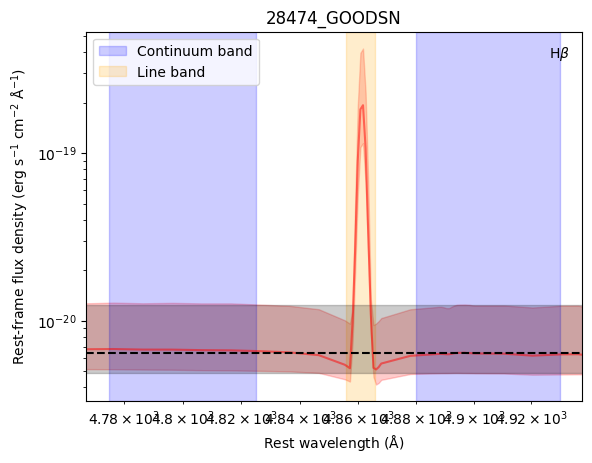

4386 2357 (2357, 4386)


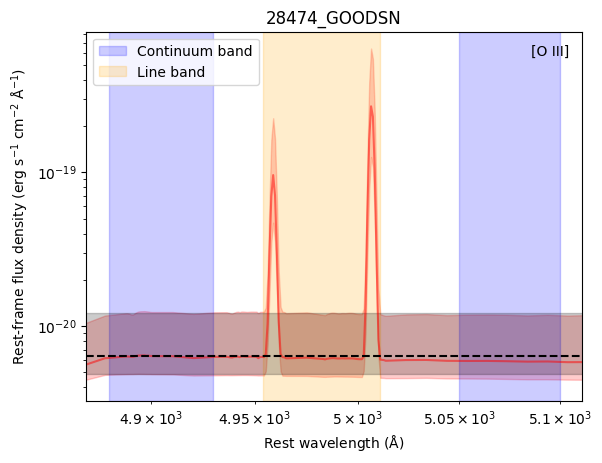

4386 2638 (2638, 4386)


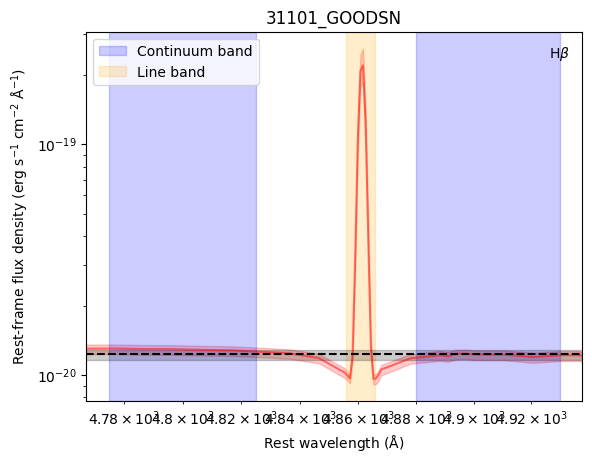

4386 2638 (2638, 4386)


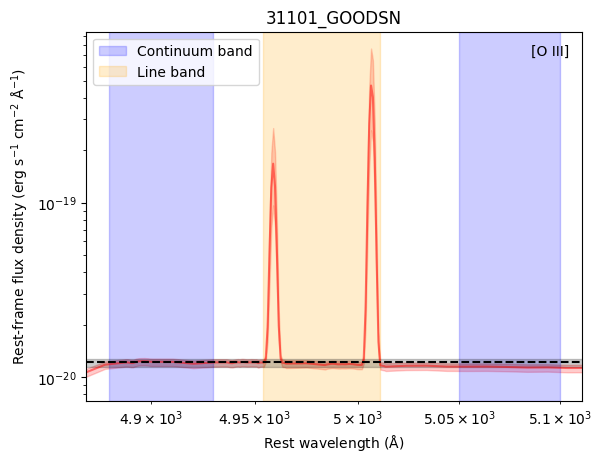

4386 2687 (2687, 4386)


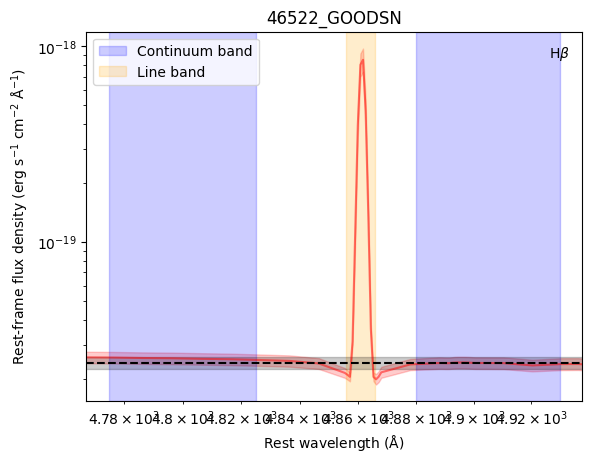

4386 2687 (2687, 4386)


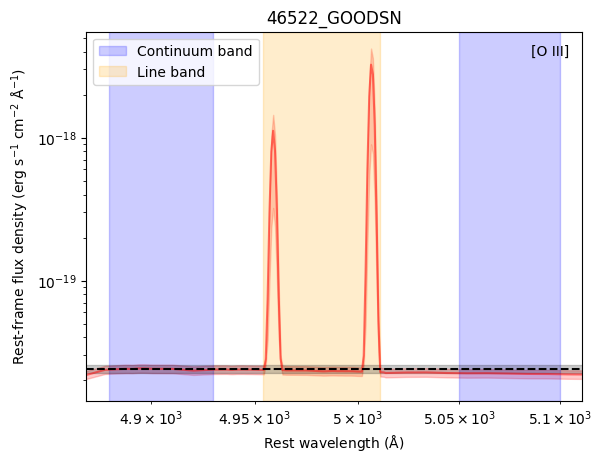

4386 2322 (2322, 4386)


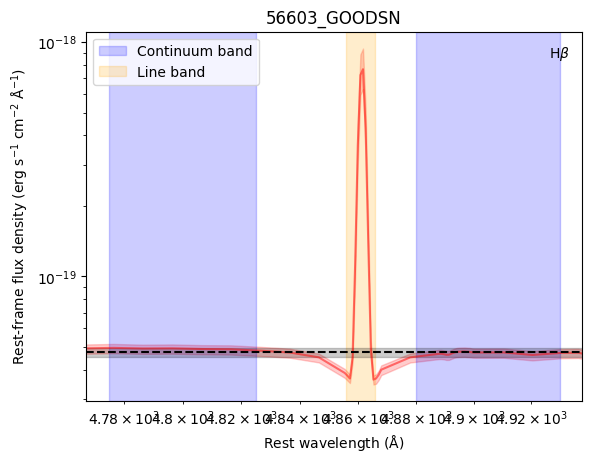

4386 2322 (2322, 4386)


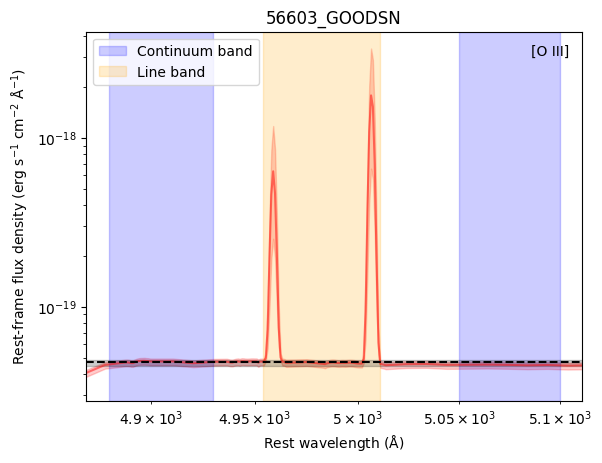

4386 1776 (1776, 4386)


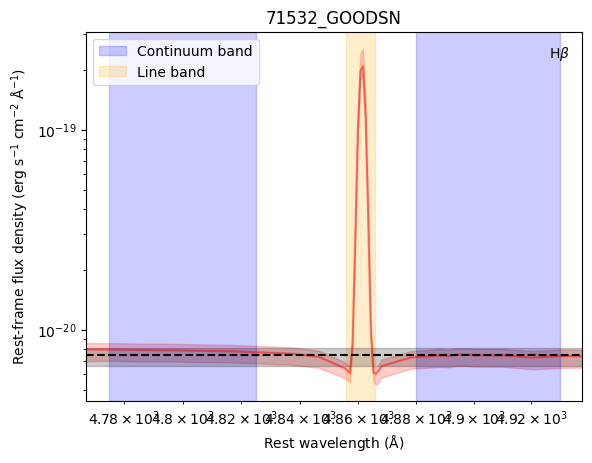

4386 1776 (1776, 4386)


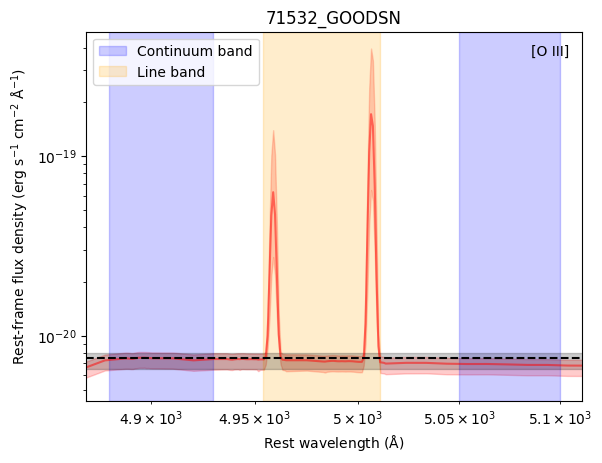

4386 2028 (2028, 4386)


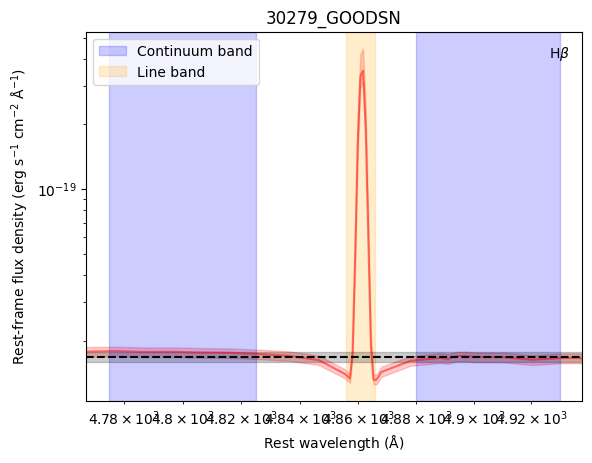

4386 2028 (2028, 4386)


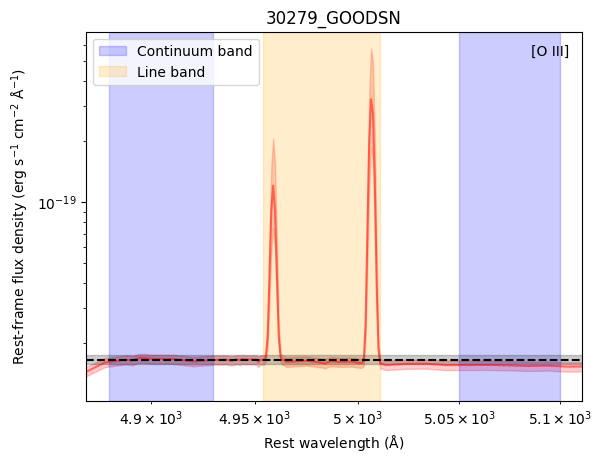

4386 1825 (1825, 4386)


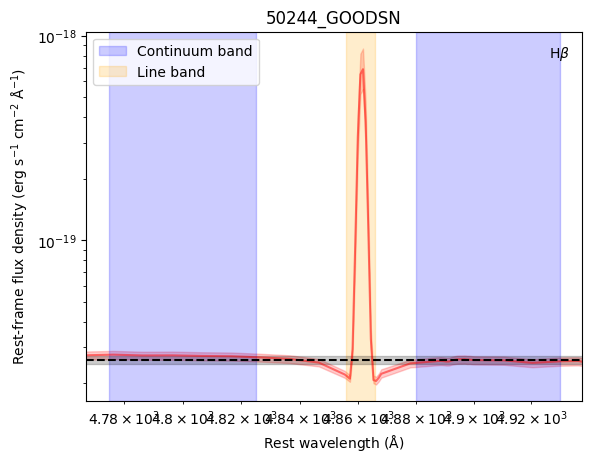

4386 1825 (1825, 4386)


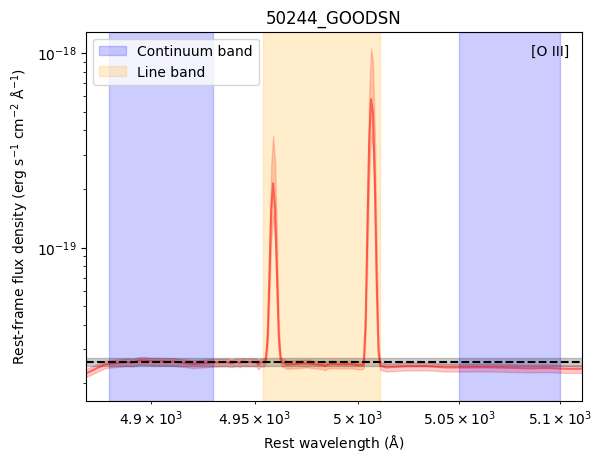

In [4]:
compare()